In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("diabetes.csv")

# Data set 
- From Kaggle
- Provided by(National Institute of Diabetes and Digestive and Kidney Diseases)

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


 # Dataset Constraints
- All patients are female
- All patients are 21 years or older
- All patients belong to Pima Indian heritage
  
 *Therefore, this dataset represents a specific demographic group and not the entire population.*
# DataSet Quality
- All numerical Data

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Data Set is already processed

In [6]:
corr=df.corr()


In [7]:
corr['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

# Glucose → 0.466
→ Moderate positive correlation with Outcomes followed by others.

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

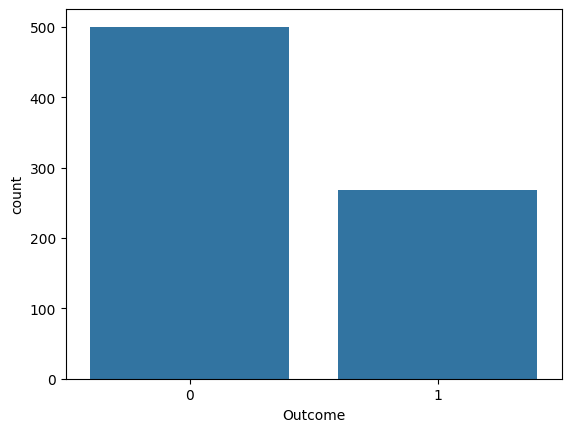

In [9]:
sns.countplot(x='Outcome',data=df)
plt.show()

# Above Countplot shows data is unbalanced, double than 1

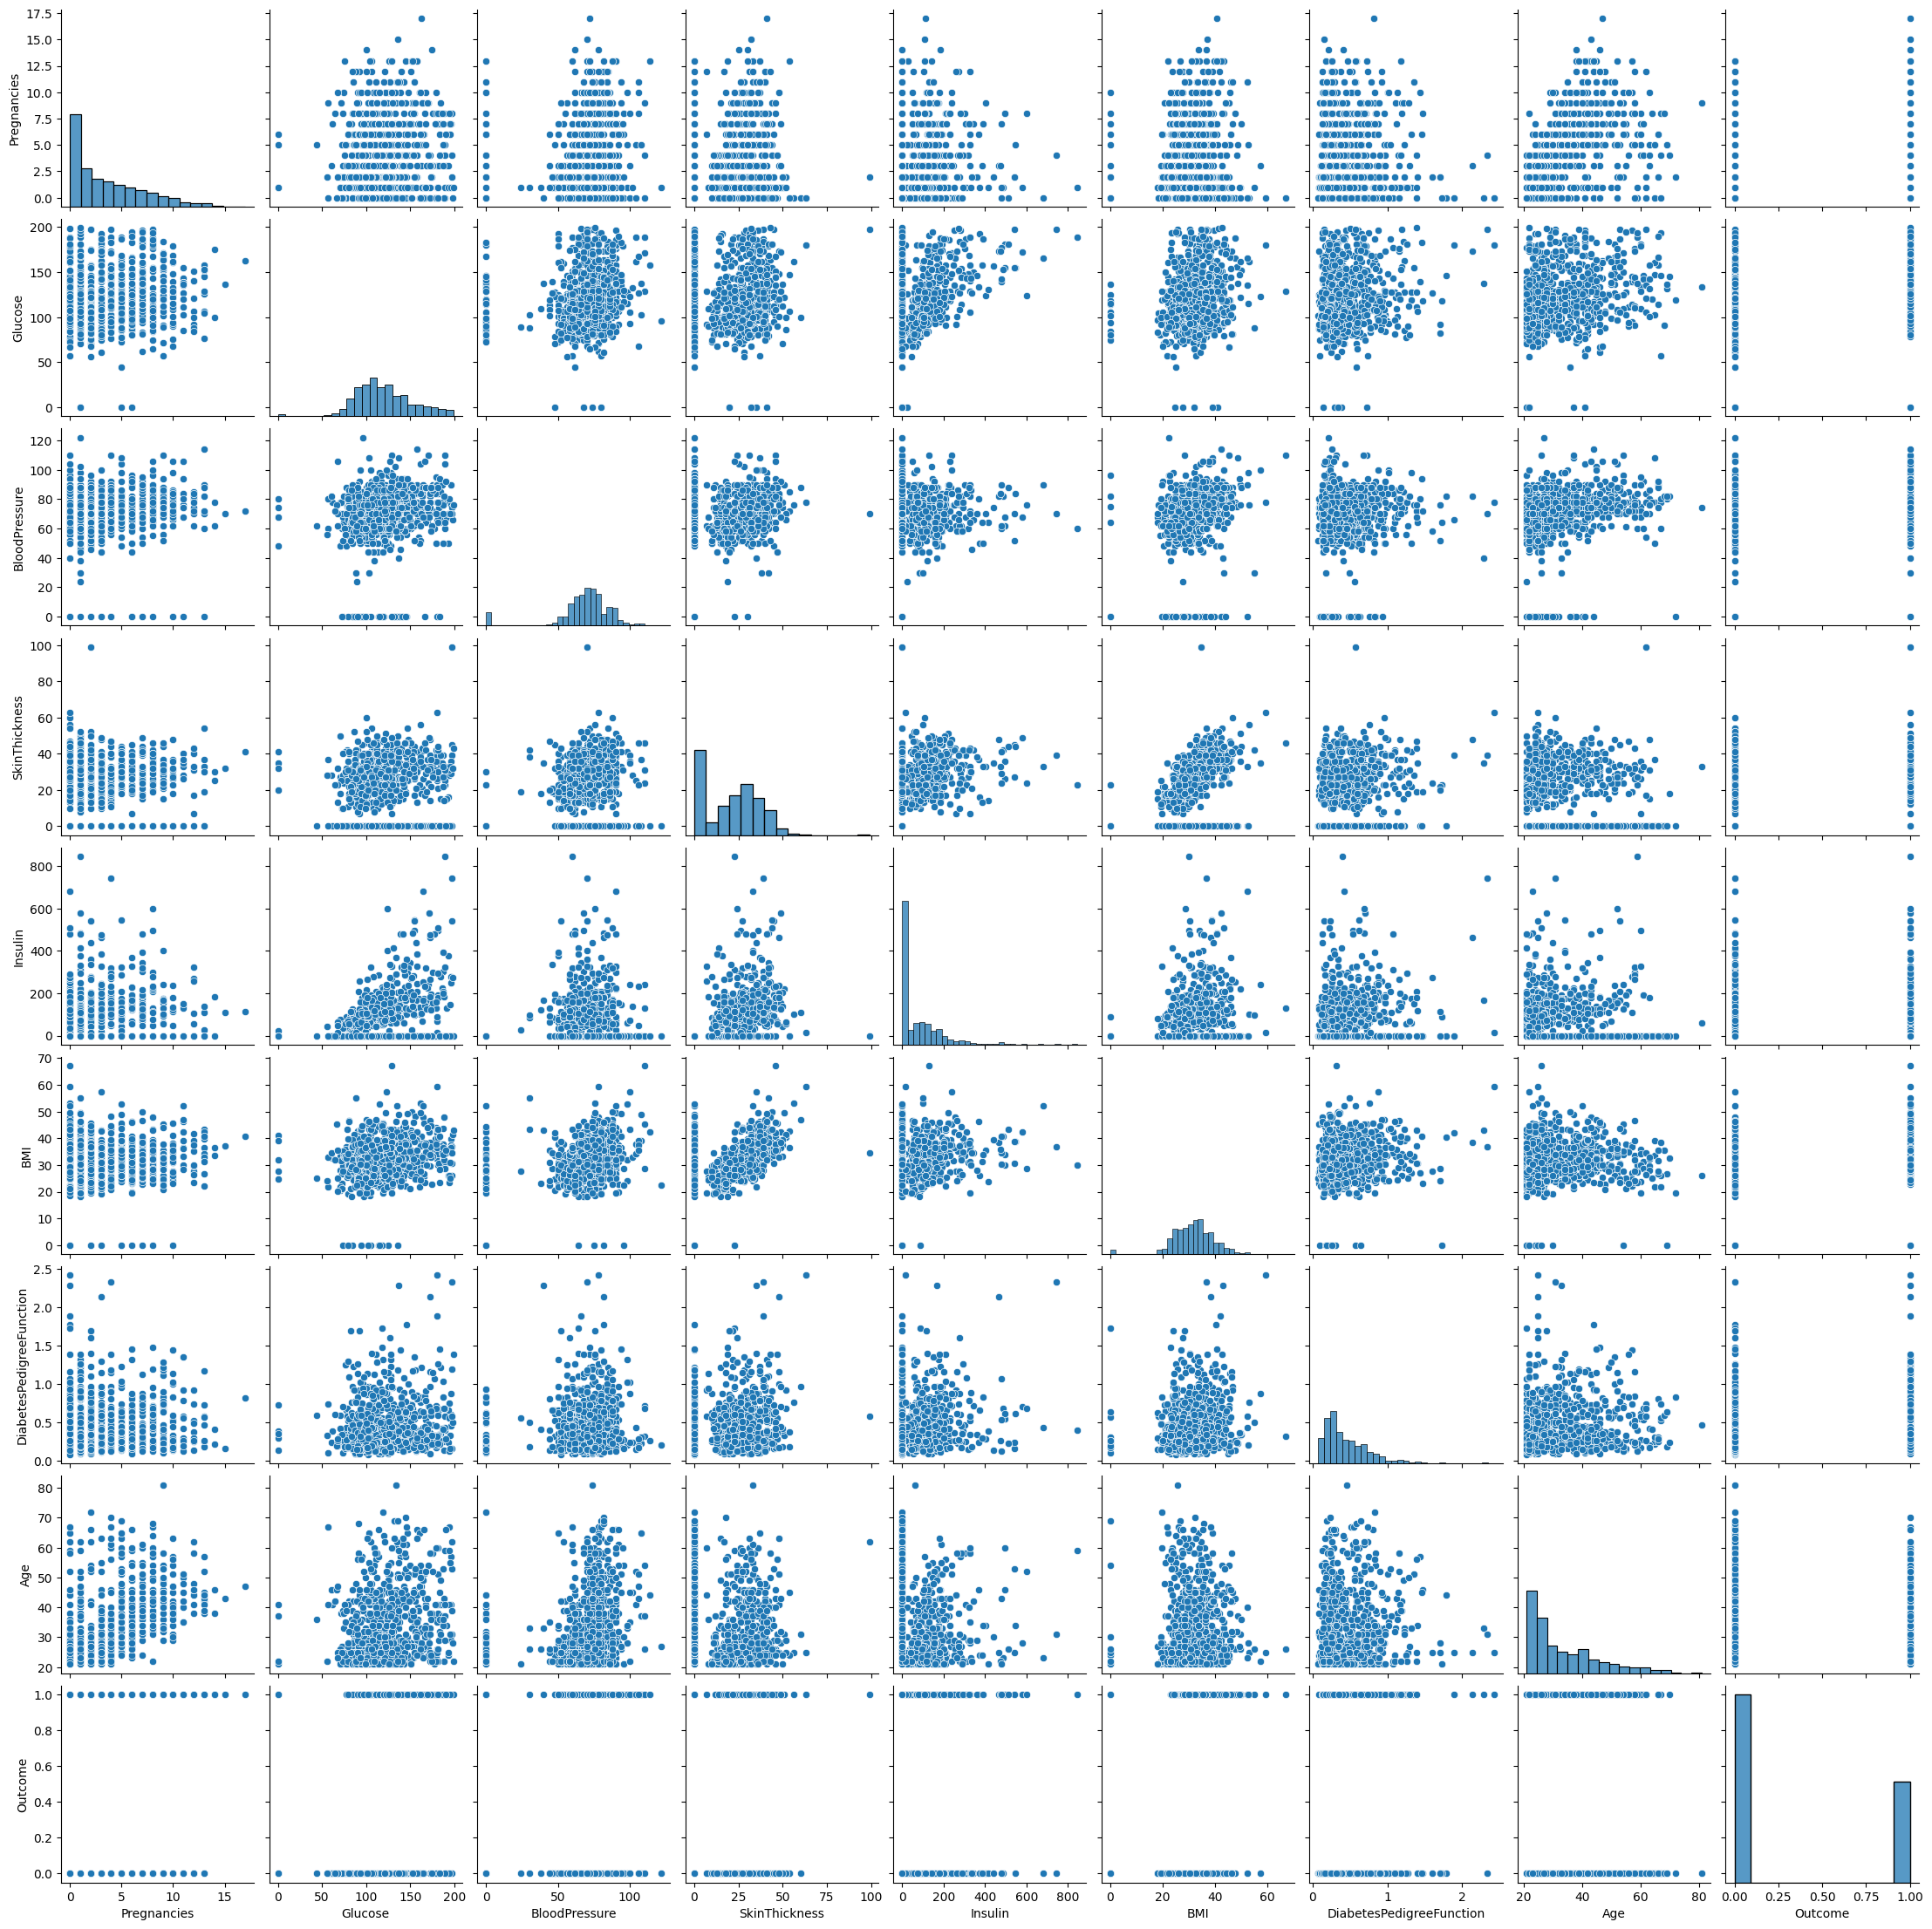

In [10]:
sns.pairplot(df)
plt.show()

([<matplotlib.patches.Wedge at 0x2056722fa10>,
 [Text(-0.5025944173008549, 0.9784676038060812, 'Class 0 (Non-Diabetic)'),
  Text(0.593975321539613, -1.1563707525711266, 'Class 1 (Diabetic)')],
 [Text(-0.2741424094368299, 0.5337096020760442, '65.1%'),
  Text(0.3655232747936079, -0.711612770813001, '34.9%')])

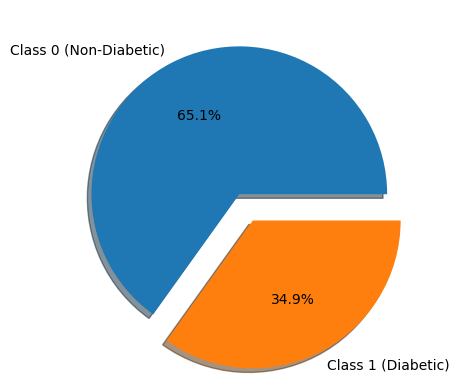

In [11]:
class_counts = df['Outcome'].value_counts()

plt.figure()
plt.pie(class_counts,
        labels=['Class 0 (Non-Diabetic)', 'Class 1 (Diabetic)'],
        autopct='%1.1f%%',shadow=True,explode=[0,0.2])

# This Shows:
- *~65% Class 0*

- *~35% Class 1*

- **Data is a very unbalanced**

In [12]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
355,9,165,88,0,0,30.4,0.302,49,1
688,1,140,74,26,180,24.1,0.828,23,0
208,1,96,64,27,87,33.2,0.289,21,0
289,5,108,72,43,75,36.1,0.263,33,0
348,3,99,62,19,74,21.8,0.279,26,0


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression


In [14]:
x=df.drop(['Outcome'],axis=1)

In [15]:
y=df['Outcome']

In [16]:
from sklearn.model_selection import train_test_split ,GridSearchCV

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
x.shape


(768, 8)

In [19]:
x_train.shape

(614, 8)

In [20]:
x_test.shape

(154, 8)

In [21]:
y.shape

(768,)

In [22]:
y_train.shape

(614,)

In [23]:
y_test.shape

(154,)

# Model Evaluation:
- Random Forest Classifier

In [24]:
rf=RandomForestClassifier()

In [25]:
param={
    'n_estimators': [50,60,70, 100,120],
    'max_depth': [20,25,35,50,80,100]
}

In [26]:
gridtr=GridSearchCV(estimator=rf,param_grid=param,cv=5)

In [27]:
gridtr.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [20, 25, ...], 'n_estimators': [50, 60, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : th

In [28]:
print("Best Parameters:", gridtr.best_params_)
print("Best Score:", gridtr.best_score_)

Best Parameters: {'max_depth': 100, 'n_estimators': 120}
Best Score: 0.7850593096094897


# Random Forest Best Parameters:
- max_depth: 100
- n_estimators: 50
- Best Score: 0.7834199

In [29]:
rfm=gridtr.best_estimator_

In [30]:
y_pred=rfm.predict(x_test)

In [31]:
report=classification_report(y_test,y_pred,output_dict=True)

In [32]:
pd.DataFrame(report).transpose()

,precision,recall,f1-score,support
0,0.800000,0.767677,0.783505,99.000000
1,0.610169,0.654545,0.631579,55.000000
accuracy,0.727273,0.727273,0.727273,0.727273
macro avg,0.705085,0.711111,0.707542,154.000000
weighted avg,0.732203,0.727273,0.729246,154.000000


# The model achieves 74% accuracy on the test dataset.
- It performs better in predicting class 0 compared to class 1, as the precision, recall, and F1-score for class 0 are higher.
- The recall for class 1 (0.67) is comparatively lower than class 0 (0.77), indicating that several positive
   instances are misclassified as negative.

# **NOW DECISION TREE**

In [33]:
dt=DecisionTreeClassifier()

In [34]:
params_griddt={
    'max_depth':[None,30,50,70,100,120],
    'min_samples_split':[2,3,4]
}

In [35]:
grid_serachdt=GridSearchCV(
    estimator=dt,
    param_grid=params_griddt,
    scoring='accuracy',
    cv=5
)

In [36]:
results_dt=grid_serachdt.fit(x_train,y_train)

In [37]:
print("Best Parameters:", results_dt.best_params_)
print("Best Score:", results_dt.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 4}
Best Score: 0.7393842463014794


# Best Parameters of decision tree: 
- max_depth: 100, min_samples_split: 4
- Best Score: 0.7377715580434494

In [38]:
from sklearn.metrics import classification_report as report

In [39]:
dt_best_estimator=results_dt.best_estimator_

In [40]:
y_preddt=dt_best_estimator.predict(x_test)

In [41]:
dt_report=report(y_test,y_preddt,output_dict=True)

In [42]:
pd.DataFrame(dt_report).transpose()

,precision,recall,f1-score,support
0,0.831579,0.797980,0.814433,99.000000
1,0.661017,0.709091,0.684211,55.000000
accuracy,0.766234,0.766234,0.766234,0.766234
macro avg,0.746298,0.753535,0.749322,154.000000
weighted avg,0.770664,0.766234,0.767925,154.000000


# The Decision Tree model achieves 76.6% accuracy on the test data.
- It performs better in predicting class 0 than class 1.
- The recall for class 1 is lower, meaning some diabetic cases are misclassified.


# Now Support Vector Classifier

In [43]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
svc = SVC()


In [44]:
pipe_svc=Pipeline([
    ("scale",StandardScaler()),
    ("svc",SVC()),
])

In [45]:
params_gridsvc=[
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 0.3, 0.5, 1]
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 0.3, 0.5, 1],
        'svc__gamma': [1, 0.1, 0.01, 0.001]
    },
    {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 0.3, 0.5, 1],
        'svc__degree': [2, 3],
        'svc__gamma': [1, 0.1, 0.01]
    }
]


In [46]:
grid_svc=GridSearchCV(
    estimator=pipe_svc,
    param_grid=params_gridsvc,
    scoring="accuracy",
    cv=5
)

In [47]:
result_grid_svc=grid_svc.fit(x_train,y_train)

In [48]:
print("Best Prameter:",result_grid_svc.best_params_)
print("Best Score:",result_grid_svc.best_score_)

Best Prameter: {'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Best Score: 0.7720111955217913


# Best Prameter SVC:
- svc__C': 1
- svc__gamma: 0.1
- svc__kernel: rbf
- **Best Score: 0.7720111955217913**

In [49]:
svc_best_estimator=result_grid_svc.best_estimator_

In [50]:
y_pred_svc=svc_best_estimator.predict(x_test)

In [51]:
svc_report=report(y_test,y_pred_svc,output_dict=True)

In [52]:
pd.DataFrame(svc_report).transpose()

,precision,recall,f1-score,support
0,0.768519,0.838384,0.801932,99.000000
1,0.652174,0.545455,0.594059,55.000000
accuracy,0.733766,0.733766,0.733766,0.733766
macro avg,0.710346,0.691919,0.697996,154.000000
weighted avg,0.726967,0.733766,0.727692,154.000000


# The SVC model achieves 73.4% accuracy on the test data.
- It performs better in predicting class 0 than class 1.
- The recall for class 1 (0.54) is quite low, meaning many diabetic cases are misclassified.
- Overall, the model shows weaker performance in detecting class 1 compared to the previous models.

# Now Logistics Regression:

In [53]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet

In [54]:
pipe_logistic=Pipeline(
    [
        ('poly',PolynomialFeatures()),
        ('scale',StandardScaler()),
        ('logi',LogisticRegression())
    ]
)

In [55]:
params_gridlr = [
    {
        'poly__degree':[1,2,3,4],
        'logi__penalty':['l2'],
        'logi__solver':['lbfgs'],
        'logi__C':[0.1,0.5,0.001,1]
    },
    {
        'poly__degree':[1,2,3,4],
        'logi__penalty':['l2'],
        'logi__solver':['liblinear'],
        'logi__C':[0.1,0.5,0.001,1]
    },
    {
        'poly__degree':[1,2,3,4],
        'logi__penalty':['l2'],
        'logi__solver':['saga'],
        'logi__C':[0.1,0.5,0.001,1]
    },
    {
        'poly__degree':[1,2,3,4],
        'logi__penalty':['l1'],
        'logi__solver':['liblinear'],
        'logi__C':[0.1,0.5,0.001,1]
    },
    {
        'poly__degree':[1,2,3,4],
        'logi__penalty':['l1'],
        'logi__solver':['saga'],
        'logi__C':[0.1,0.5,0.001,1]
    },
    {
        'poly__degree':[1,2,3,4],
        'logi__penalty':['elasticnet'],
        'logi__solver':['saga'],
        'logi__C':[0.1,0.5,0.001,1],
        'logi__l1_ratio':[0.2,0.3,0.5,0.7]
    }
]


In [56]:
grid_lg=GridSearchCV(
    estimator=pipe_logistic,
    param_grid=params_gridlr,
    scoring="accuracy",
    cv=5
           
)

In [57]:
import warnings
warnings.filterwarnings("ignore")

In [58]:
results_gridlg=grid_lg.fit(x_train,y_train)

In [59]:
print("Best Parameters: ", results_gridlg.best_params_)
print("Best Score:",results_gridlg.best_score_)

Best Parameters:  {'logi__C': 0.1, 'logi__penalty': 'l1', 'logi__solver': 'saga', 'poly__degree': 2}
Best Score: 0.7704251632680261


# Best Parameters:  
- logi__C: 0.1
- logi__penalty: l1
- logi__solver: saga
- poly__degree: 2
- **Best Score: 0.7704251632680261**

In [60]:
best_estlg=results_gridlg.best_estimator_

In [61]:
y_predlg=best_estlg.predict(x_test)

In [62]:
results_gridlg.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [63]:
report_lg=report(y_predlg,y_test,output_dict=True)

In [64]:
pd.DataFrame(report_lg).transpose()

,precision,recall,f1-score,support
0,0.838384,0.798077,0.817734,104.00000
1,0.618182,0.680000,0.647619,50.00000
accuracy,0.759740,0.759740,0.759740,0.75974
macro avg,0.728283,0.739038,0.732677,154.00000
weighted avg,0.766890,0.759740,0.762502,154.00000


# The model achieves 75.97% accuracy on the test data.
- It performs better in predicting class 0 than class 1.
- The recall for class 1 (0.68) is lower than class 0 (0.79), meaning some diabetic cases are misclassified.

In [65]:
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score

In [66]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Decision Tree", "SVC", 
              "Logistic Regression"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_preddt),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_predlg)
        
    ],
    
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_preddt),
        precision_score(y_test, y_pred_svc),
        precision_score(y_test, y_predlg)
    ],
    "F1 score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_preddt),
        f1_score(y_test, y_pred_svc),
        f1_score(y_test, y_predlg)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_preddt),
        recall_score(y_test, y_pred_svc),
        recall_score(y_test, y_predlg)]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,F1 score,Recall
1,Decision Tree,0.766234,0.661017,0.684211,0.709091
3,Logistic Regression,0.759740,0.680000,0.647619,0.618182
2,SVC,0.733766,0.652174,0.594059,0.545455
0,Random Forest,0.727273,0.610169,0.631579,0.654545


# Table is evaluating how well models detect diabetes (class 1) only.

# All metrics shown are calculated for class 1 (diabetic cases) since binary averaging is used.

- Among the models, Decision Tree performs best, with the highest accuracy (76.6%), recall (0.69), and F1-score (0.67). This means it             detects diabetic cases better than the other models.

- Logistic Regression has slightly higher precision but lower recall, meaning it misses more diabetic cases.

- Since recall is important in medical prediction, Decision Tree is the most suitable model for this task.

### **Decision Tree achieved the highest recall and overall balanced performance. Since recall is important in medical prediction, it was selected as the final model. The dataset shows class imbalance, which may affect performance and can be addressed in future work using techniques such as class weighting or SMOTE.**